# Imports

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import json
from datasets import Dataset
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

c:\Users\User\miniconda3\envs\FYPenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# SAMPLE EXTRACTION - MENTIONS

CHOICES:
- 1400 to Train 1000, and test on 400 -> Values gotten via sample calculator 

In [ ]:
INPUT_CSV = Path("Data/Articles/Output/Articles2024_mentions.csv")
OUTPUT_CSV = Path("Data/Articles/Output/Articles2024_mentions_sample_stratified.csv")

SAMPLE_SIZE = 1400
MAX_MENTIONS_PER_ARTICLE = 2
RANDOM_SEED = 42
MIN_PER_CODE = 15   # minimum sample target per nationality code

df = pd.read_csv(INPUT_CSV).copy()

# Basic checks
for col in ["article_id", "sentence", "code"]:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

df["sentence"] = df["sentence"].astype(str).str.strip()
df = df[df["sentence"].ne("") & df["sentence"].ne("nan")].copy()

df = df.reset_index(drop=True)
df["mention_id"] = np.arange(1, len(df) + 1)

# Randomize and cap mentions per article
df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
df = df.groupby("article_id", group_keys=False).head(MAX_MENTIONS_PER_ARTICLE).copy()

# Compute proportional sample allocation by nationality code
code_counts = df["code"].value_counts().sort_index()
proportions = code_counts / code_counts.sum()
alloc = (proportions * SAMPLE_SIZE).round().astype(int)

# Enforce a small minimum where possible
for code in alloc.index:
    if code_counts[code] >= MIN_PER_CODE and alloc[code] < MIN_PER_CODE:
        alloc[code] = MIN_PER_CODE

# Adjust total allocation back to SAMPLE_SIZE
diff = alloc.sum() - SAMPLE_SIZE

if diff > 0:
    # remove extras from largest allocations first
    for code in alloc.sort_values(ascending=False).index:
        while diff > 0 and alloc[code] > MIN_PER_CODE:
            alloc[code] -= 1
            diff -= 1
        if diff == 0:
            break

elif diff < 0:
    # add missing slots to largest groups
    diff = abs(diff)
    for code in alloc.sort_values(ascending=False).index:
        available_extra = code_counts[code] - alloc[code]
        while diff > 0 and available_extra > 0:
            alloc[code] += 1
            diff -= 1
            available_extra -= 1
        if diff == 0:
            break

# Draw sample within each code
parts = []
for code, n in alloc.items():
    group = df[df["code"] == code]
    n = min(n, len(group))
    if n > 0:
        parts.append(group.sample(n=n, random_state=RANDOM_SEED))

sample_df = pd.concat(parts, ignore_index=True)

# If rounding left us short, fill randomly from leftovers
if len(sample_df) < SAMPLE_SIZE:
    already = set(sample_df["mention_id"])
    leftovers = df[~df["mention_id"].isin(already)]
    extra_n = min(SAMPLE_SIZE - len(sample_df), len(leftovers))
    if extra_n > 0:
        extra = leftovers.sample(n=extra_n, random_state=RANDOM_SEED)
        sample_df = pd.concat([sample_df, extra], ignore_index=True)

sample_df = sample_df.drop_duplicates(subset=["mention_id"]).copy()

# Trim
if len(sample_df) > SAMPLE_SIZE:
    sample_df = sample_df.sample(n=SAMPLE_SIZE, random_state=RANDOM_SEED).copy()

# Annotation columns
keep_cols = [c for c in [
    "mention_id", "article_id", "code", "surface", "method", "label",
    "section", "sentence", "paragraph", "char_start", "char_end"
] if c in sample_df.columns]

sample_df = sample_df[keep_cols].copy()
sample_df["sentiment_ground_truth"] = ""
sample_df["sentiment_reasoning"] = ""

sample_df = sample_df.sort_values(["code", "article_id", "mention_id"]).reset_index(drop=True)

OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
sample_df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")

print(f"Saved stratified sample to: {OUTPUT_CSV}")
print("Final shape:", sample_df.shape)
print(sample_df["code"].value_counts().head(20))

Saved stratified sample to: Data\Articles\Output\Articles2024_mentions_sample_stratified.csv
Final shape: (1400, 13)
code
MLT    548
ITA     61
GBR     60
FRA     31
PSE     24
RUS     23
IND     22
USA     21
AUS     15
AUT     15
BEL     15
BGD     15
BGR     15
BRA     15
CAN     15
CHN     15
COL     15
DEU     15
DNK     15
EGY     15
Name: count, dtype: int64


# LABELLING

THEN THE CSV EXTRACTED WAS LABELLED, AND SAVED IN Data/Articles as Articles2024_mentions_sample_labelled.csv

# Training on Sentence-level (Mention-level) Labelled Sentiment

In [ ]:
# Config
set_seed(42)

CSV_PATH = "Data/Articles/Articles2024_mentions_sample_labelled.csv"  # <-- change if needed
TEXT_COLS = ["sentence"]
LABEL_COL = "sentiment_ground_truth"

BASE_MODEL = "cardiffnlp/twitter-xlm-roberta-base-sentiment" #"xlm-roberta-large"
OUTPUT_DIR = "./sentiment_finetuned_xlmr_mentions"

label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}

# Small tuning grid
LEARNING_RATES = [1e-5, 2e-5, 3e-5]
EPOCH_OPTIONS = [3, 4, 5]
SEEDS = [42, 7, 123]


TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 2


# Helper Functions
def normalize_label(x):
    if pd.isna(x):
        return None
    x = str(x).strip().lower()
    mapping = {
        "negative": "negative",
        "neutral": "neutral",
        "positive": "positive",
    }
    return mapping.get(x, None)

def build_text(row):
    # Only the sentence is given
    # I took this choice to not get any potential bias from the surface form itself (which varies by country)
    sentence = row.get("sentence")
    if pd.notna(sentence) and str(sentence).strip():
        return str(sentence).strip()
    return ""

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted}

# Load + prepare data
set_seed(42)

df = pd.read_csv(CSV_PATH, low_memory=False)
df.columns = df.columns.str.strip()

df["text"] = df.apply(build_text, axis=1)
df["label_str"] = df[LABEL_COL].apply(normalize_label)

df = df.dropna(subset=["text", "label_str"]).copy()
df = df[df["text"].str.strip() != ""].copy()

df["label"] = df["label_str"].map(label2id)

model_df = df.copy()

# Fixed test split so every tuning run is comparable
train_val_df, test_df = train_test_split(
    model_df,
    test_size=400,
    random_state=42,
    stratify=model_df["label"],
)

print("Total rows used:", len(model_df))
print("Train+Val size:", len(train_val_df))
print("Test size:", len(test_df))
print("Label distribution (full):")
print(model_df["label_str"].value_counts(dropna=False))
print("Label distribution (test):")
print(test_df["label_str"].value_counts(dropna=False))

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True)

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=512,
    )

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Hyperparameter grid
results = []

for seed in SEEDS:
    set_seed(seed)

    train_df, val_df = train_test_split(
        train_val_df,
        test_size=0.15,
        random_state=seed,
        stratify=train_val_df["label"],
    )

    print("\n====================================")
    print(f"Seed {seed}")
    print("Train size:", len(train_df))
    print("Validation size:", len(val_df))
    print("====================================")

    train_ds = Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False)
    val_ds = Dataset.from_pandas(val_df[["text", "label"]], preserve_index=False)

    train_ds = train_ds.map(tokenize_fn, batched=True)
    val_ds = val_ds.map(tokenize_fn, batched=True)

    for lr in LEARNING_RATES:
        for num_epochs in EPOCH_OPTIONS:
            run_name = f"seed{seed}_lr{lr}_ep{num_epochs}"
            run_dir = os.path.join(OUTPUT_DIR, run_name)

            print(f"\n=== Running {run_name} ===")

            model = AutoModelForSequenceClassification.from_pretrained(
                BASE_MODEL,
                num_labels=3,
                label2id=label2id,
                id2label=id2label,
            )

            args = TrainingArguments(
                output_dir=run_dir,
                learning_rate=lr,
                per_device_train_batch_size=TRAIN_BATCH_SIZE,
                per_device_eval_batch_size=EVAL_BATCH_SIZE,
                gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
                num_train_epochs=num_epochs,
                weight_decay=0.01,
                eval_strategy="epoch",
                save_strategy="epoch",
                save_only_model=True,
                save_total_limit=1,
                load_best_model_at_end=True,
                metric_for_best_model="f1_macro",
                logging_steps=50,
                fp16=torch.cuda.is_available(),
                report_to="none",
                seed=seed,
            )

            trainer = Trainer(
                model=model,
                args=args,
                train_dataset=train_ds,
                eval_dataset=val_ds,
                data_collator=data_collator,
                compute_metrics=compute_metrics,
            )

            trainer.train()
            val_metrics = trainer.evaluate()

            results.append({
                "seed": seed,
                "learning_rate": lr,
                "epochs": num_epochs,
                "eval_accuracy": val_metrics.get("eval_accuracy"),
                "eval_f1_macro": val_metrics.get("eval_f1_macro"),
                "eval_f1_weighted": val_metrics.get("eval_f1_weighted"),
                "run_dir": run_dir,
            })

# Rank all runs
results_df = pd.DataFrame(results).sort_values(
    ["eval_f1_macro", "eval_accuracy"],
    ascending=False
).reset_index(drop=True)

print("\nTop runs:")
print(results_df.head(10))

best_row = results_df.iloc[0]
best_seed = int(best_row["seed"])
best_lr = float(best_row["learning_rate"])
best_epochs = int(best_row["epochs"])

print("\nBest config:")
print(best_row)

# Retrain best config and evaluate on fixed test set
set_seed(best_seed)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.15,
    random_state=best_seed,
    stratify=train_val_df["label"],
)

train_ds = Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False)
val_ds = Dataset.from_pandas(val_df[["text", "label"]], preserve_index=False)
test_ds = Dataset.from_pandas(test_df[["text", "label"]], preserve_index=False)

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds = val_ds.map(tokenize_fn, batched=True)
test_ds = test_ds.map(tokenize_fn, batched=True)

best_model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=3,
    label2id=label2id,
    id2label=id2label,
)

final_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    learning_rate=best_lr,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    num_train_epochs=best_epochs,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_only_model=True,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=best_seed,
)

final_trainer = Trainer(
    model=best_model,
    args=final_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

final_trainer.train()

# Test evaluation
test_out = final_trainer.predict(test_ds)
test_preds = np.argmax(test_out.predictions, axis=-1)
test_labels = test_out.label_ids

print("Test accuracy:", accuracy_score(test_labels, test_preds))
print("Test report:\n")
print(classification_report(
    test_labels,
    test_preds,
    target_names=[id2label[i] for i in range(3)]
))

# Save final model + tokenizer
final_trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

with open(os.path.join(OUTPUT_DIR, "best_config.json"), "w", encoding="utf-8") as f:
    json.dump({
        "base_model": BASE_MODEL,
        "seed": best_seed,
        "learning_rate": best_lr,
        "epochs": best_epochs,
        "train_batch_size": TRAIN_BATCH_SIZE,
        "eval_batch_size": EVAL_BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    }, f, indent=2)

print("Saved to:", OUTPUT_DIR)


Total rows used: 1398
Train+Val size: 998
Test size: 400
Label distribution (full):
label_str
neutral     548
positive    484
negative    366
Name: count, dtype: int64
Label distribution (test):
label_str
neutral     157
positive    138
negative    105
Name: count, dtype: int64

Seed 42
Train size: 848
Validation size: 150


Map: 100%|██████████| 150/150 [00:00<00:00, 14420.68 examples/s]



=== Running seed42_lr1e-05_ep3 ===


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 592.23it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.774011,0.887384,0.533333,0.495078,0.518993
2,1.400852,0.884325,0.573333,0.565777,0.575289
3,1.213331,0.891659,0.606667,0.603636,0.610068


...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.724800,0.843046,0.580000,0.582657,0.581605
2,1.174387,0.900965,0.620000,0.616243,0.626214
3,0.598464,1.130197,0.660000,0.657256,0.665417
4,0.246292,1.499444,0.673333,0.665880,0.676215
5,0.087324,1.737799,0.660000,0.651727,0.663511


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.71s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

Test accuracy: 0.6725
Test report:

              precision    recall  f1-score   support

    negative       0.69      0.60      0.64       105
     neutral       0.64      0.72      0.68       157
    positive       0.70      0.67      0.69       138

    accuracy                           0.67       400
   macro avg       0.68      0.66      0.67       400
weighted avg       0.67      0.67      0.67       400



Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.65s/it]

Saved to: ./sentiment_finetuned_xlmr_mentions


# Evaluate Sentence-level Model

<Figure size 700x600 with 0 Axes>

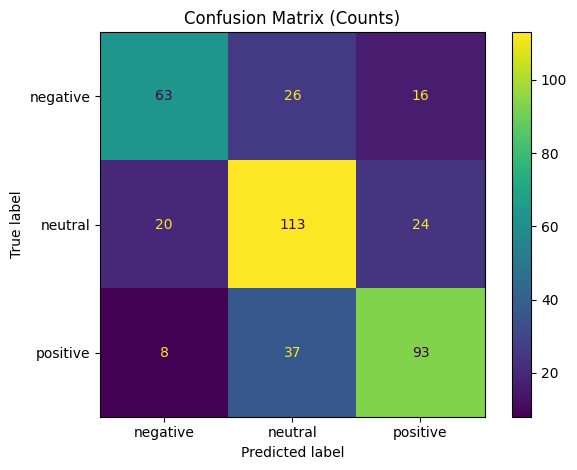

<Figure size 700x600 with 0 Axes>

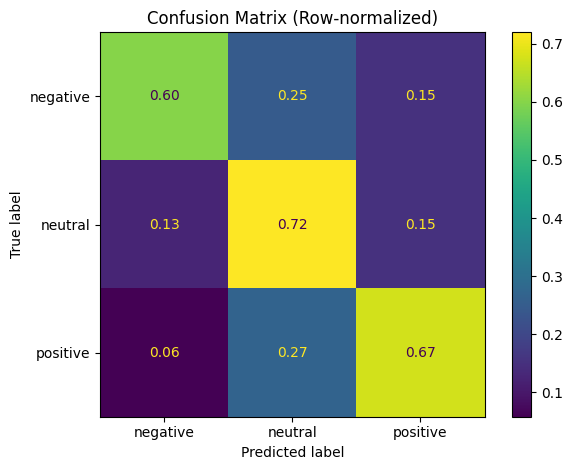

Total test examples: 400
Total misclassified: 131
Misclassification rate: 0.3275

First 20 misclassified examples:
    article_id      surface  \
0       346238      Maltese   
2       327996       Syrian   
5       307894      Maltese   
8       309762      Maltese   
14        5547      Maltese   
15      255201      Chinese   
17      316067      Belgian   
20      325918      Maltese   
21      304696  Bangladeshi   
39      370239     Japanese   
41      307535      Maltese   
43        8734       German   
45      330129      Maltese   
46      487562      Serbian   
48      354388      Maltese   
53        8540      Serbian   
54      364863      Chinese   
55      337436  Bangladeshi   
59        7057      Italian   
61      390406      Swedish   

                                             sentence true_label pred_label  
0   The Maltese MEP elections were certainly event...    neutral   negative  
2   Initial investigations revealed the 78-year-ol...   negative    neutral  

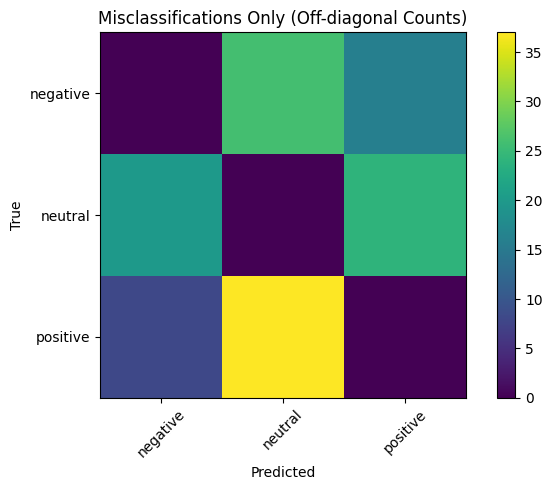


Saved misclassified rows to: misclassified_mentions.csv


In [ ]:
# Prepare readable labels
label_order = [id2label[i] for i in range(len(id2label))]

true_names = [id2label[int(x)] for x in test_labels]
pred_names = [id2label[int(x)] for x in test_preds]

# Safer alignment with predictions
test_df_reset = test_df.reset_index(drop=True).copy()

# Raw confusion matrix

cm = confusion_matrix(test_labels, test_preds, labels=list(range(len(label_order))))

plt.figure(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
disp.plot(values_format="d")
plt.title("Confusion Matrix (Counts)")
plt.tight_layout()
plt.show()

# Normalized confusion matrix (row-normalized)
cm_norm = confusion_matrix(
    test_labels,
    test_preds,
    labels=list(range(len(label_order))),
    normalize="true"
)

plt.figure(figsize=(7, 6))
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=label_order)
disp_norm.plot(values_format=".2f")
plt.title("Confusion Matrix (Row-normalized)")
plt.tight_layout()
plt.show()

# Misclassification dataframe
misclassified_df = test_df_reset.copy()
misclassified_df["true_label"] = true_names
misclassified_df["pred_label"] = pred_names
misclassified_df["correct"] = misclassified_df["true_label"] == misclassified_df["pred_label"]

# Add confidence / predicted probabilities if you want
probs = torch.softmax(torch.tensor(test_out.predictions), dim=-1).numpy()
misclassified_df["pred_confidence"] = probs.max(axis=1)

errors_df = misclassified_df[~misclassified_df["correct"]].copy()

print("Total test examples:", len(misclassified_df))
print("Total misclassified:", len(errors_df))
print("Misclassification rate:", round(len(errors_df) / len(misclassified_df), 4))

# Show some useful columns
error_cols = [c for c in [
    "article_id",
    "surface",
    "sentence",
    "true_label",
    "pred_label",
] if c in errors_df.columns]

print("\nFirst 20 misclassified examples:")
print(errors_df[error_cols].head(20))

# Misclassification pattern table
misclassification_table = pd.crosstab(
    pd.Series(true_names, name="True"),
    pd.Series(pred_names, name="Predicted")
)

print("\nMisclassification table:")
print(misclassification_table)

# Plot only the off-diagonal misclassifications
off_diag = misclassification_table.copy()
for lab in label_order:
    if lab in off_diag.index and lab in off_diag.columns:
        off_diag.loc[lab, lab] = 0

plt.figure(figsize=(7, 5))
plt.imshow(off_diag.values)
plt.xticks(range(len(off_diag.columns)), off_diag.columns, rotation=45)
plt.yticks(range(len(off_diag.index)), off_diag.index)
plt.colorbar()
plt.title("Misclassifications Only (Off-diagonal Counts)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Training on Article-level Labelled Sentiment

In [ ]:
# Config
set_seed(42)

CSV_PATH = "Data/Articles/Articles2024_batch_labelled.csv" 
TEXT_COLS = ["title", "subtitle", "content"]
LABEL_COL = "sentiment_ground_truth"

BASE_MODEL = "cardiffnlp/twitter-xlm-roberta-base-sentiment"  # multilingual and strong
OUTPUT_DIR = "./sentiment_finetuned_xlmr"

label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}

def normalize_label(x):
    if pd.isna(x):
        return None
    x = str(x).strip().lower()
    mapping = {
        "negative": "negative",
        "neutral": "neutral",
        "positive": "positive",
    }
    return mapping.get(x, None)

def build_text(row):
    parts = []
    for c in TEXT_COLS:
        v = row.get(c)
        if pd.notna(v) and str(v).strip():
            parts.append(str(v).strip())
    return "\n".join(parts)

# Load + prepare data
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()

# Build combined text + normalized labels
df["text"] = df.apply(build_text, axis=1)
df["label_str"] = df[LABEL_COL].apply(normalize_label)

# Drop missing
df = df.dropna(subset=["text", "label_str"]).copy()

# Map to ids
df["label"] = df["label_str"].map(label2id)

# train/val/test split
train_df, test_df = train_test_split(
    df, test_size=0.15, random_state=42, stratify=df["label"]
)
train_df, val_df = train_test_split(
    train_df, test_size=0.15, random_state=42, stratify=train_df["label"]
)

train_ds = Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False)
val_ds   = Dataset.from_pandas(val_df[["text", "label"]], preserve_index=False)
test_ds  = Dataset.from_pandas(test_df[["text", "label"]], preserve_index=False)

# Tokenizer / model
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True)

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=512, 
    )

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)
test_ds  = test_ds.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=3,
    label2id=label2id,
    id2label=id2label,
)

# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted}

# Training args
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_only_model=True,        # avoids saving optimizer (the process was crashing)
    save_total_limit=1,        # keep only last checkpoint
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    fp16=torch.cuda.is_available() if "torch" in globals() else False,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Train
trainer.train()

# Evaluate on test
test_out = trainer.predict(test_ds)
test_preds = np.argmax(test_out.predictions, axis=-1)
test_labels = test_out.label_ids

print("Test accuracy:", accuracy_score(test_labels, test_preds))
print("Test report:\n")
print(classification_report(test_labels, test_preds, target_names=[id2label[i] for i in range(3)]))

# Save final model + tokenizer
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("Saved to:", OUTPUT_DIR)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 301.95it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.918599,0.668588,0.710938,0.675410,0.712398
2,0.624020,0.601300,0.750000,0.698481,0.734096
3,0.421218,0.637697,0.726562,0.671942,0.709342


Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.52s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

Test accuracy: 0.76
Test report:

              precision    recall  f1-score   support

    negative       0.79      0.87      0.83        60
     neutral       0.57      0.49      0.52        35
    positive       0.83      0.82      0.83        55

    accuracy                           0.76       150
   macro avg       0.73      0.72      0.72       150
weighted avg       0.75      0.76      0.75       150



Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.42s/it]

Saved to: ./sentiment_finetuned_xlmr
